In [4]:
import numpy as np

In [29]:
x , y , z  = np.arange(1,6,1) , np.arange(6,11,1) , np.arange(11,16,1)
u = np.array([1,1,1])
M = np.array([x,y,z]).T
um = np.dot(M,u)
M

array([[ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14],
       [ 5, 10, 15]])

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def von_mises_fisher_distribution(theta, kappa, dim):
    """
    Calcula la probabilidad de la distribución de Von Mises-Fisher en el punto theta.

    Parameters:
    - theta: Vector de dirección (numpy array).
    - kappa: Parámetro de concentración.
    - dim: Dimensión del espacio.

    Returns:
    - prob: Probabilidad en el punto theta.
    """
    norm_theta = np.linalg.norm(theta)
    prefactor = (kappa ** (dim / 2.0 - 1)) / ((2 * np.pi) ** (dim / 2.0) * np.math.factorial(dim / 2.0 - 1))
    prob = prefactor * np.exp(kappa * np.dot(np.array([1] + [0] * (dim - 1)), theta))

    return prob

def plot_von_mises_fisher(dim, kappa, num_points=1000):
    """
    Grafica la distribución de Von Mises-Fisher en el espacio 2D o 3D.

    Parameters:
    - dim: Dimensión del espacio (2 o 3).
    - kappa: Parámetro de concentración.
    - num_points: Número de puntos para la visualización.

    Returns:
    - None
    """
    if dim not in [2, 3]:
        raise ValueError("La dimensión debe ser 2 o 3.")

    if dim == 2:
        # Generar puntos en el círculo unitario
        angles = np.linspace(0, 2 * np.pi, num_points)
        points = np.array([np.cos(angles), np.sin(angles)])

        # Calcular la probabilidad en cada punto
        probabilities = [von_mises_fisher_distribution(point, kappa, dim) for point in points.T]

        # Graficar la distribución
        plt.plot(angles, probabilities)
        plt.title(f'Distribución de Von Mises-Fisher en 2D (kappa={kappa})')
        plt.xlabel('Ángulo')
        plt.ylabel('Probabilidad')
        plt.show()
    elif dim == 3:
        # Generar puntos en la superficie de la esfera
        phi = np.linspace(0, np.pi, num_points)
        theta = np.linspace(0, 2 * np.pi, num_points)
        phi, theta = np.meshgrid(phi, theta)

        # Convertir coordenadas esféricas a cartesianas
        x = np.sin(phi) * np.cos(theta)
        y = np.sin(phi) * np.sin(theta)
        z = np.cos(phi)

        # Calcular la probabilidad en cada punto
        probabilities = np.array([[von_mises_fisher_distribution(np.array([x[i, j], y[i, j], z[i, j]]), kappa, dim)
                                   for j in range(num_points)] for i in range(num_points)])

        # Graficar la distribución
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(x, y, probabilities, cmap='viridis')
        ax.set_title(f'Distribución de Von Mises-Fisher en 3D (kappa={kappa})')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Probabilidad')
        plt.show()

# Parámetros de ejemplo
dimension = 3
concentration_parameter = 5.0

# Graficar la distribución de Von Mises-Fisher
plot_von_mises_fisher(dimension, concentration_parameter)


TypeError: 'float' object cannot be interpreted as an integer

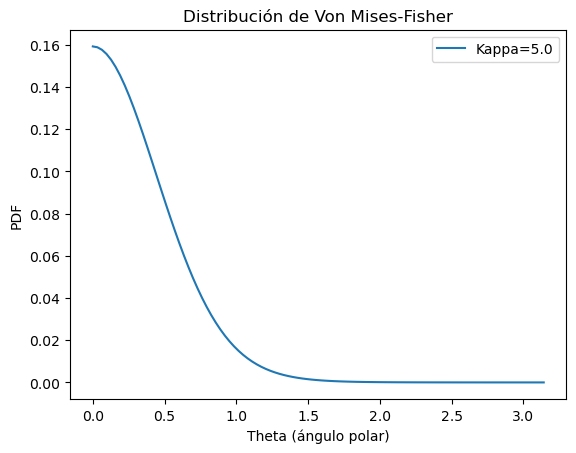

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def von_mises_fisher_pdf(theta, kappa, d):
    """
    Calcula la función de densidad de probabilidad (pdf) de la distribución de Von Mises-Fisher.

    Parameters:
    - theta: Ángulos polar (colatitud) de las muestras.
    - kappa: Parámetro de concentración.
    - d: Dimensión del espacio (2 para 2D, 3 para 3D, etc.).

    Returns:
    - pdf: Valor de la pdf para cada ángulo theta.
    """
    C = np.exp(kappa * np.cos(theta)) / (2 * np.pi * (np.exp(kappa) - np.exp(-kappa)))
    return C

# Parámetros de la distribución de Von Mises-Fisher
kappa = 5.0  # Parámetro de concentración
d = 2  # Dimensión del espacio (2D en este caso)

# Generar ángulos theta en el rango [0, pi] para 2D
theta = np.linspace(0, np.pi, 100)

# Calcular la pdf de Von Mises-Fisher para cada ángulo theta
pdf_values = von_mises_fisher_pdf(theta, kappa, d)

# Graficar la distribución de Von Mises-Fisher en 2D
plt.plot(theta, pdf_values, label=f'Kappa={kappa}')
plt.title('Distribución de Von Mises-Fisher')
plt.xlabel('Theta (ángulo polar)')
plt.ylabel('PDF')
plt.legend()
plt.show()


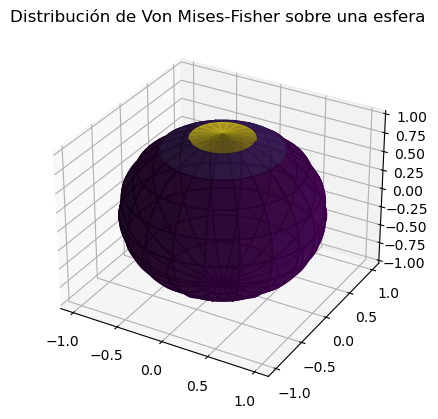

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def von_mises_fisher_pdf(theta, phi, kappa):
    """
    Calcula la función de densidad de probabilidad (pdf) de la distribución de Von Mises-Fisher.

    Parameters:
    - theta: Ángulos azimutales de las muestras.
    - phi: Ángulos de colatitud de las muestras.
    - kappa: Parámetro de concentración.

    Returns:
    - pdf: Valor de la pdf para cada par de ángulos (theta, phi).
    """
    C = (kappa / (2 * np.pi * (np.exp(kappa) - np.exp(-kappa)))) * np.exp(kappa * np.cos(phi))
    return C

# Parámetros de la distribución de Von Mises-Fisher
kappa = 100  # Parámetro de concentración

# Generar ángulos theta y phi en el rango [0, 2*pi] y [0, pi] respectivamente
theta = np.linspace(0, 2 * np.pi, 100)
phi = np.linspace(0, np.pi, 50)

# Crear una malla de coordenadas theta, phi
theta, phi = np.meshgrid(theta, phi)

# Calcular la pdf de Von Mises-Fisher para cada par de ángulos (theta, phi)
pdf_values = von_mises_fisher_pdf(theta, phi, kappa)

# Convertir coordenadas esféricas a cartesianas para la visualización en 3D
x = np.sin(phi) * np.cos(theta)
y = np.sin(phi) * np.sin(theta)
z = np.cos(phi)

# Graficar la distribución de Von Mises-Fisher en una esfera en 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, facecolors=plt.cm.viridis(pdf_values), rstride=5, cstride=5, alpha=0.8, antialiased=True)

ax.set_title('Distribución de Von Mises-Fisher sobre una esfera')
plt.show()


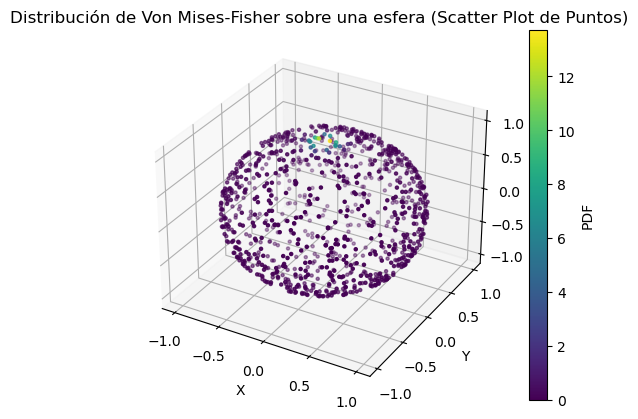

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def von_mises_fisher_pdf(theta, phi, kappa):
    """
    Calcula la función de densidad de probabilidad (pdf) de la distribución de Von Mises-Fisher.

    Parameters:
    - theta: Ángulos azimutales de las muestras.
    - phi: Ángulos de colatitud de las muestras.
    - kappa: Parámetro de concentración.

    Returns:
    - pdf: Valor de la pdf para cada par de ángulos (theta, phi).
    """
    C = (kappa / (2 * np.pi * (np.exp(kappa) - np.exp(-kappa)))) * np.exp(kappa * np.cos(phi))
    return C

# Parámetros de la distribución de Von Mises-Fisher
kappa = 100  # Parámetro de concentración

# Generar ángulos theta y phi aleatorios
theta = np.random.uniform(0, 2 * np.pi, 1000)
phi = np.arccos(np.random.uniform(-1, 1, 1000))

# Calcular la pdf de Von Mises-Fisher para cada par de ángulos (theta, phi)
# pdf_values = von_mises_fisher_pdf(theta, phi, kappa)

# Convertir coordenadas esféricas a cartesianas para la visualización en 3D
x = np.sin(phi) * np.cos(theta)
y = np.sin(phi) * np.sin(theta)
z = np.cos(phi)
mu = np.array([0,0,1])
ang = np.arccos((mu[0]*x + mu[1]*y + mu[2]*z)/(np.linalg.norm(mu)))
pdf_values = von_mises_fisher_pdf(theta, ang, kappa)

# Graficar la distribución de Von Mises-Fisher sobre una esfera como un scatter plot en 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, z, c=pdf_values, cmap='viridis', s=5)

ax.set_title('Distribución de Von Mises-Fisher sobre una esfera (Scatter Plot de Puntos)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
fig.colorbar(sc, label='PDF')
plt.show()


In [86]:
import numpy as np

delta = 0.5
alpha = np.pi/2
chi = np.pi/4

# alpha , chi = 0, np.pi/4

R = np.array(
    [
        [np.exp(1j*delta),0],
        [0,1]
    ]
)

T_lineal = np.array(
    [
        [np.cos(alpha)*np.cos(chi) - 1j*np.sin(alpha)*np.sin(chi) ,np.cos(alpha)*np.sin(chi) + 1j*np.sin(alpha)*np.cos(chi)],
        [np.sin(alpha)*np.cos(chi) + 1j*np.cos(alpha)*np.sin(chi) ,np.sin(alpha)*np.sin(chi) - 1j*np.cos(alpha)*np.cos(chi)]
    ]
)

# T_lineal = np.array(
#     [
#         [np.cos(alpha)*np.cos(chi) + 1j*np.sin(alpha)*np.sin(chi) ,np.cos(alpha)*np.sin(chi) - 1j*np.sin(alpha)*np.cos(chi)],
#         [np.sin(alpha)*np.cos(chi) - 1j*np.cos(alpha)*np.sin(chi) ,np.sin(alpha)*np.sin(chi) + 1j*np.cos(alpha)*np.cos(chi)]
#     ]
# )

JonesVec = np.array([np.cos(alpha)*np.cos(chi) - 1j*np.sin(alpha)*np.sin(chi),
                     np.sin(alpha)*np.cos(chi)+1j*np.cos(alpha)*np.sin(chi)])


R_t = np.dot(np.linalg.inv(T_lineal),np.dot(R,T_lineal))

sigma0,sigma1,sigma3,sigma2 = np.array([[1,0],[0,1]]),np.array([[1,0],[0,-1]]),np.array([[0,1],[1,0]]),np.array([[0,-1j],[1j,0]])
Sigma = np.array([sigma0,sigma1,sigma2,sigma3])
S = np.array([1,np.cos(2*alpha)*np.cos(2*chi),np.cos(2*alpha)*np.sin(2*chi),np.sin(2*chi)])

# R_tq = np.exp(1j*np.dot(Sigma.T,S).T*delta/2)
R_tq = np.cos(delta/2)*sigma0 + 1j*np.sin(delta/2)*np.dot(Sigma[1:].T,S[1:]).T
R_tq

array([[ 0.96891242-1.51491233e-17j, -0.24740396+2.47403959e-01j],
       [ 0.24740396+2.47403959e-01j,  0.96891242+1.51491233e-17j]])

In [72]:
R_t

array([[0.93879128+0.23971277j, 0.06120872-0.23971277j],
       [0.06120872-0.23971277j, 0.93879128+0.23971277j]])

In [73]:
np.array(
    [
        [np.cos(delta/2)+1j*np.cos(2*alpha)*np.cos(2*chi)*np.sin(delta/2), (1j*np.cos(2*alpha)*np.sin(2*chi)-np.sin(2*chi))*np.sin(delta/2)],
        [(1j*np.cos(2*alpha)*np.sin(2*chi)+np.sin(2*chi))*np.sin(delta/2),np.cos(delta/2)-1j*np.cos(2*alpha)*np.cos(2*chi)*+np.sin(delta/2)]
    ]
)

array([[ 0.96891242-1.51491233e-17j, -0.24740396-2.47403959e-01j],
       [ 0.24740396-2.47403959e-01j,  0.96891242+1.51491233e-17j]])

In [67]:
np.cos(2*alpha)*np.cos(2*chi)*np.sin(delta/2)

-1.5149123339871685e-17

In [50]:
a = np.array([1,2,3])
b , c , d = np.zeros((2,2)) , np.zeros((2,2)) , np.zeros((2,2))
b[0,:] , c[1,:] , d[1,:] = 1 , 1 , 2 
m = np.array([b,c,d])
m

array([[[1., 1.],
        [0., 0.]],

       [[0., 0.],
        [1., 1.]],

       [[0., 0.],
        [2., 2.]]])

In [51]:
a[0]*m[0] + a[1]*m[1] + a[2]*m[2]

array([[1., 1.],
       [8., 8.]])

In [52]:
np.dot(m.T,a)

array([[1., 8.],
       [1., 8.]])

In [70]:
a = np.array([1+2j,1j])
np.outer(a,np.conjugate(a))

array([[5.+0.j, 2.-1.j],
       [2.+1.j, 1.+0.j]])

In [42]:
np.dot(m,a.T)

array([[6., 0., 0.],
       [0., 6., 0.],
       [0., 0., 6.]])

In [83]:
xd = np.pi/4
r = np.array([1,0,1,0])
np.cos(xd/2)*sigma0 + 1j*np.sin(xd/2)*np.dot(Sigma[1:].T,r[1:]).T

array([[ 0.92387953+0.j,  0.38268343+0.j],
       [-0.38268343+0.j,  0.92387953+0.j]])

In [84]:
np.exp(1j*np.dot(Sigma.T,S).T*xd/2)

array([[0.92387953+0.38268343j, 0.62383294+0.25840006j],
       [1.36824034+0.5667437j , 0.92387953+0.38268343j]])